<div style="width: 100%; overflow: hidden;">
    <a href="http://www.uc.pt/fctuc/dei/">
    <div style="display: block;margin-left: auto;margin-right: auto; width: 100%;"><img src="https://eden.dei.uc.pt/~naml/images_ecos/dei25.png"  /></div>
    </a>
</div>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
%matplotlib inline
# Just to make plots look better
plt.rcParams["figure.figsize"] = (20,12)
plt.rcParams['axes.grid'] = True
plt.style.use('fivethirtyeight')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['lines.linewidth'] = 3

<h2><font color='#3498db'>3. Introduction</font></h2>
The main goal of this class is introduce the <a href="https://numpy.org">Numpy</a>, <a href="https://pandas.pydata.org">Pandas</a> and <a href="https://seaborn.pydata.org">Seaborn</a> libraries. In recent years these libraries have become essential in scientific computation and Machine Learning, due to their highly intuitive syntax, and high performance capabilities.

<h2><font color='#3498db'>Seaborn</font></h2>
Seaborn is a Python visualization library based on `matplotlib`. It provides a high-level interface for drawing attractive and informative statistical graphics.

Seaborn is built to provide appealing plots and at the same time it making developers’ life easier. We have all been in a situation where we needed to build a simple decent looking plot. It is built on top of Matplotlib and provides a high level API that makes “a well-defined set of hard things easy” (as stated in the documentation).

The main advantage of Seaborn is that it is part of the PyData stack, and it accepts Pandas data structures, which makes our life easier.

Lets start making some visualisations.





#### Histogram
One of the first things we do when start exploring data is to try to understand the distribution of variables (i.e., features) we have. For instance, lets consider our cars dataset, and try to understand the distribution of the prices.

<Axes: xlabel='Price', ylabel='Count'>

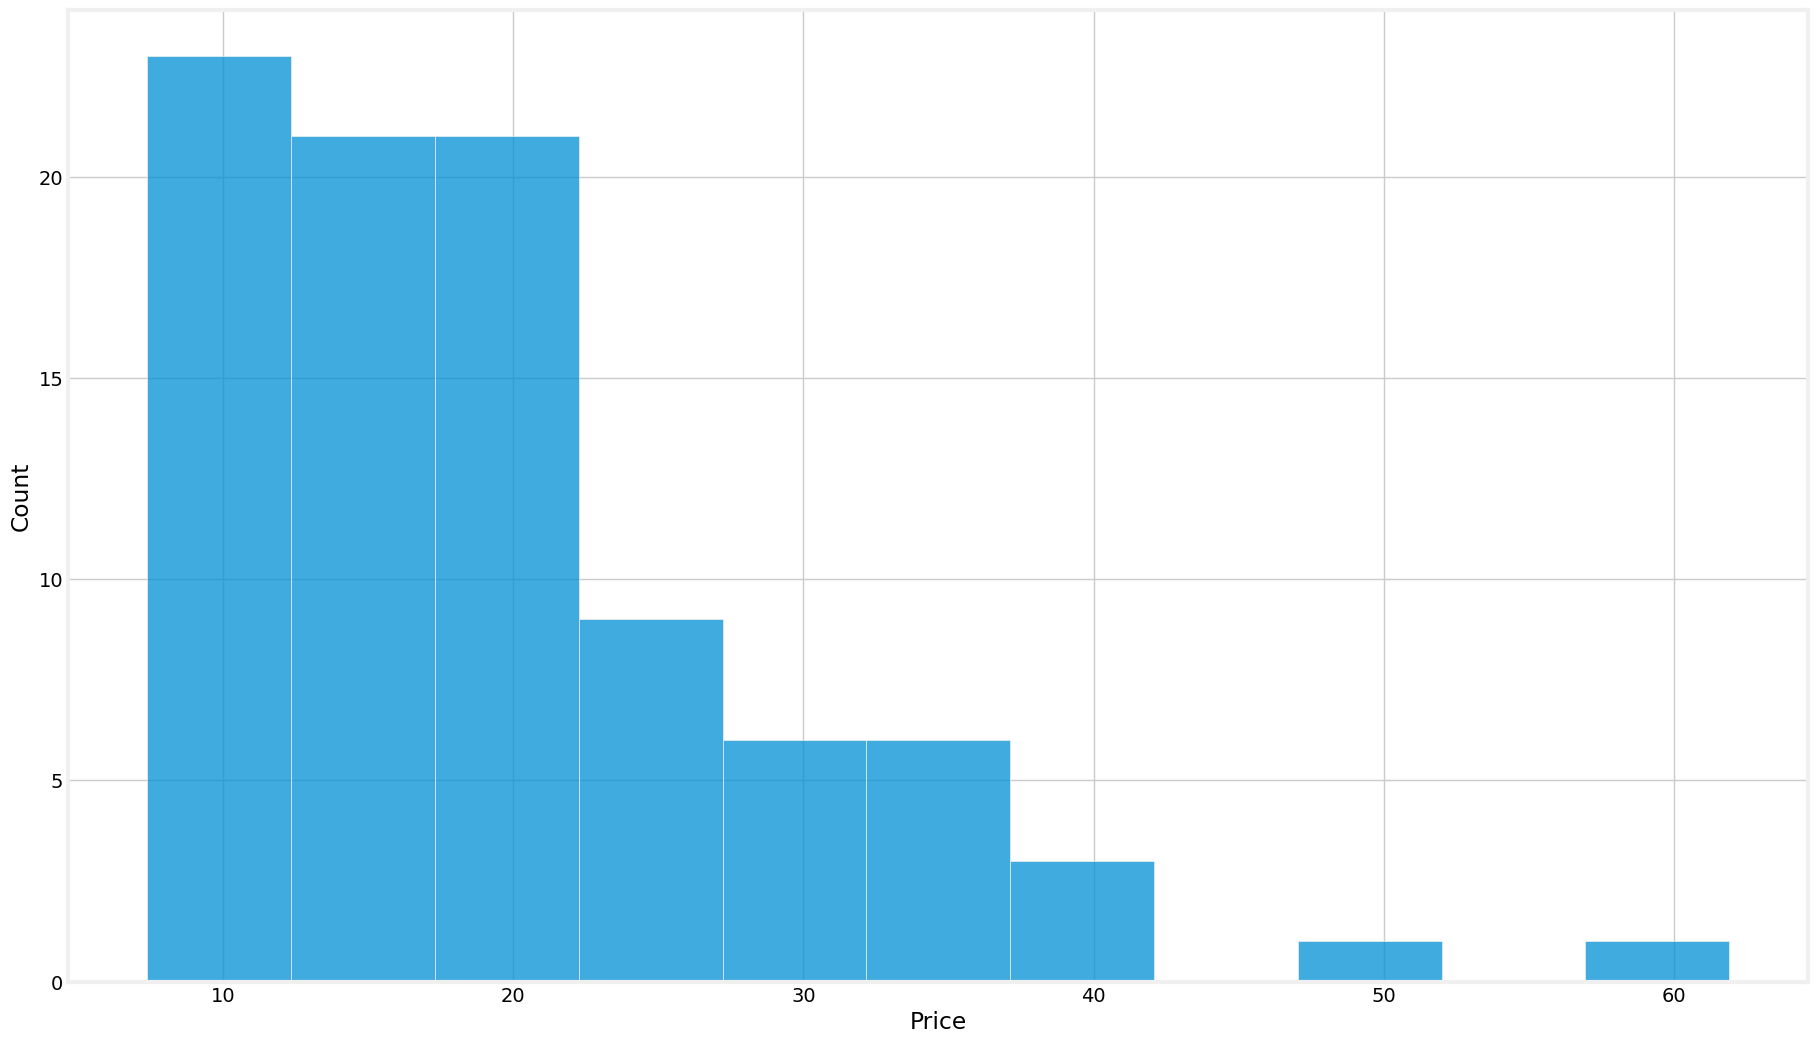

In [7]:
df_cars = pd.read_csv('../assets/cars.csv')
sns.histplot(df_cars['Price'])

We can also plot the kernel density estimation (kde) which provides us with an estimate of the probability density function. To that, we just have to pass the argument `kde=True`

<Axes: xlabel='Price', ylabel='Count'>

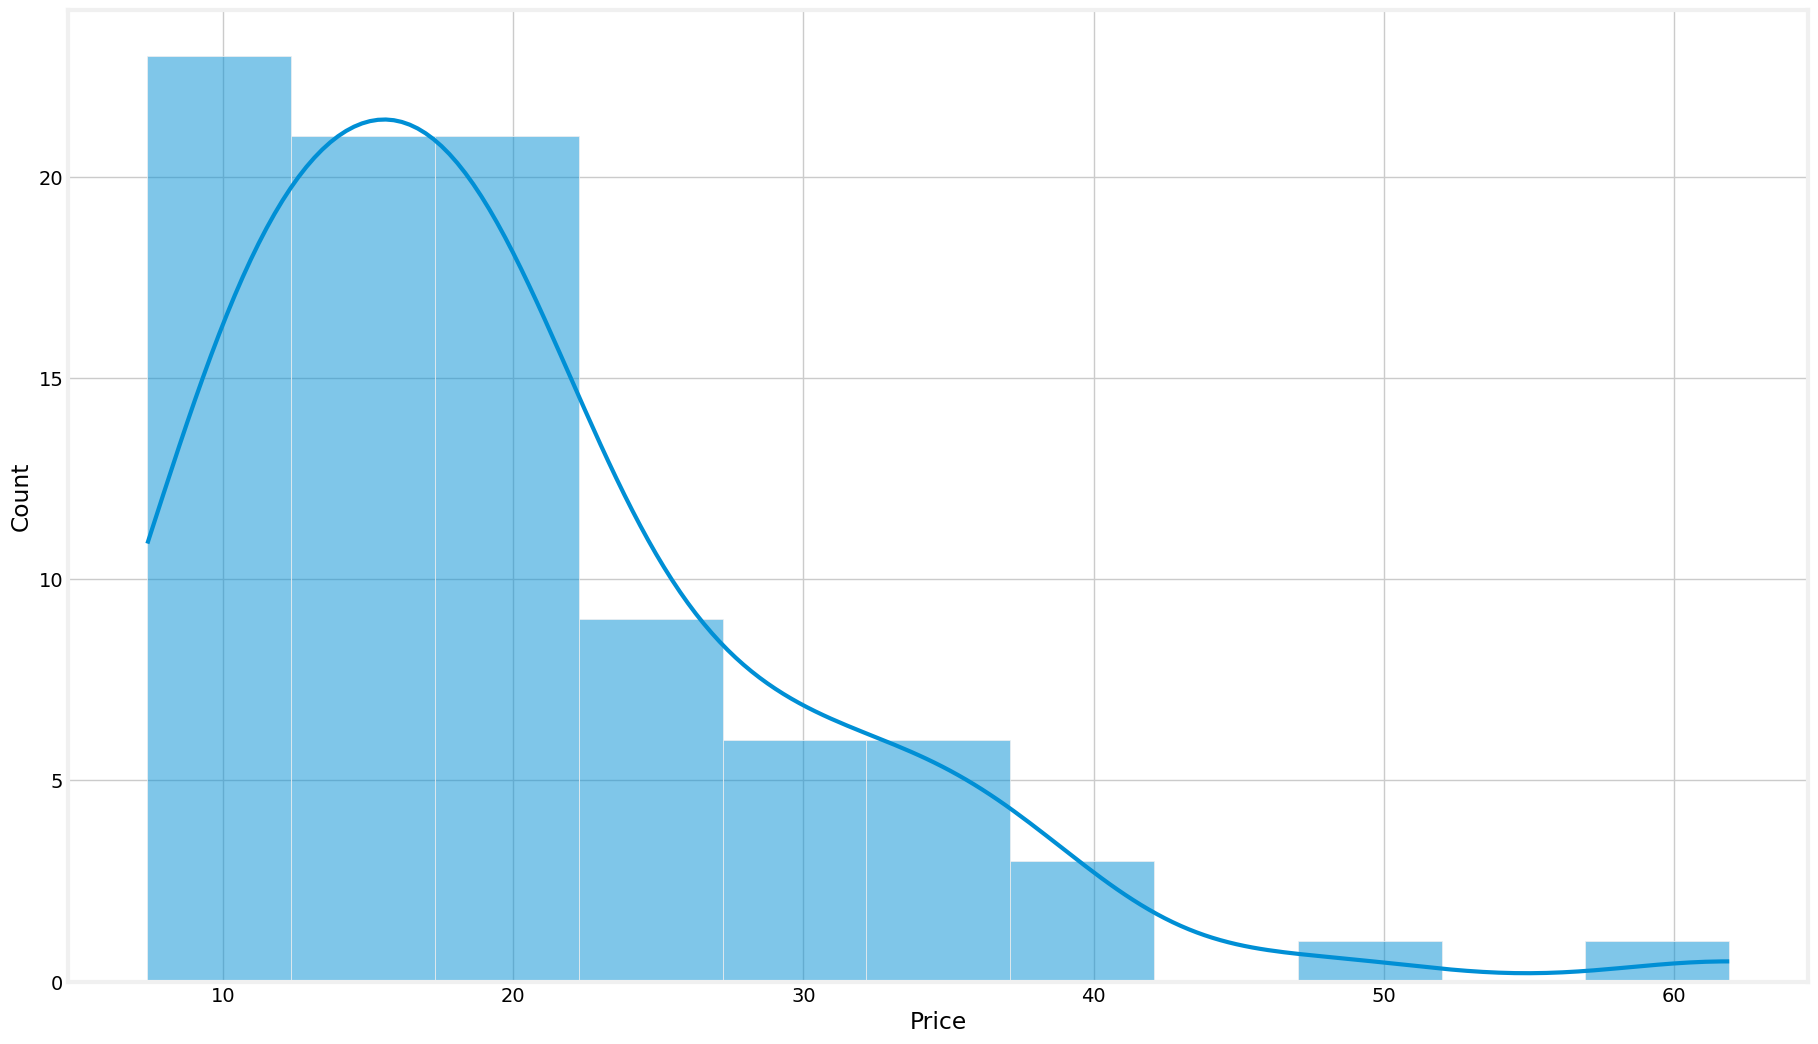

In [3]:
sns.histplot(df_cars['Price'], kde=True)

#### FacetGrid
If we want to create a plot by categories, we can use the `FacetGrid`. For instance, assume that we want to understand the distribution of prices by type and origin. 

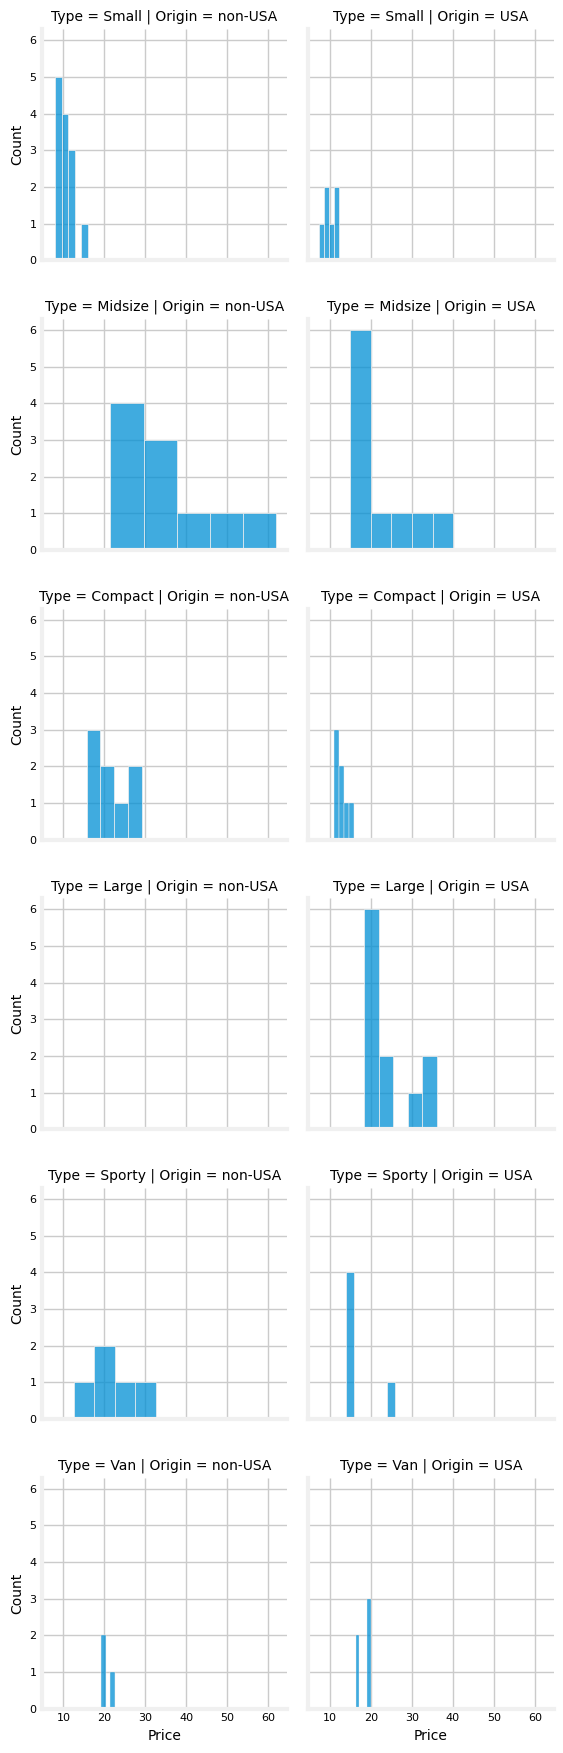

In [4]:
g = sns.FacetGrid(df_cars, row='Type', col='Origin')
g.map(sns.histplot, 'Price')
g.set_titles(size=10)
g.set_axis_labels('Price', 'Count', fontsize=10)
for ax in g.axes.flat:
    ax.tick_params(labelsize=8)

#### jointplot
This method is used to display data points according to two variables, along with their distributions, kernel density estimators, and an optional regression that fits the data.

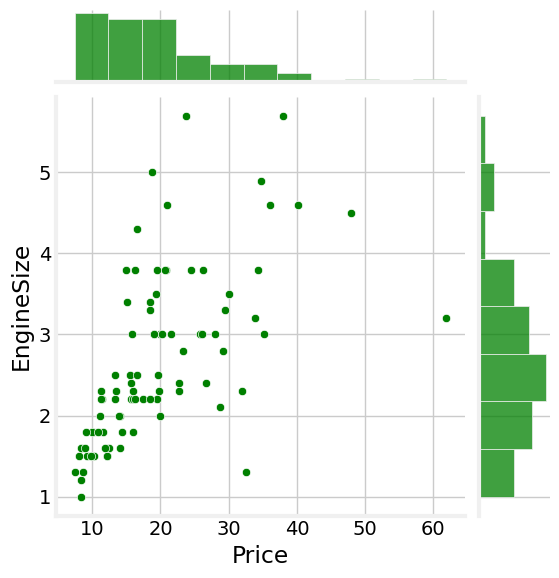

In [5]:
sns.jointplot(data=df_cars, x='Price', y='EngineSize', color='g')

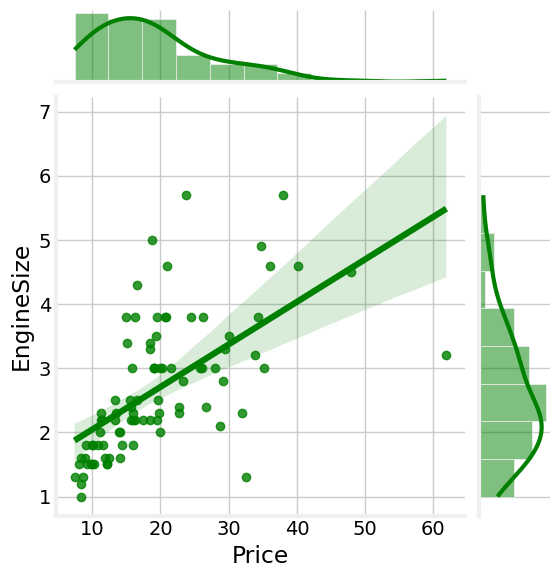

In [6]:
sns.jointplot(data=df_cars, x='Price', y='EngineSize', color='g', kind='reg')

#### Heatmap
Heatmaps are ideal to plot matrixes. They are great to visualize when some values, or calculated values, such as averages, counts, correlations present extreme values.

<Axes: >

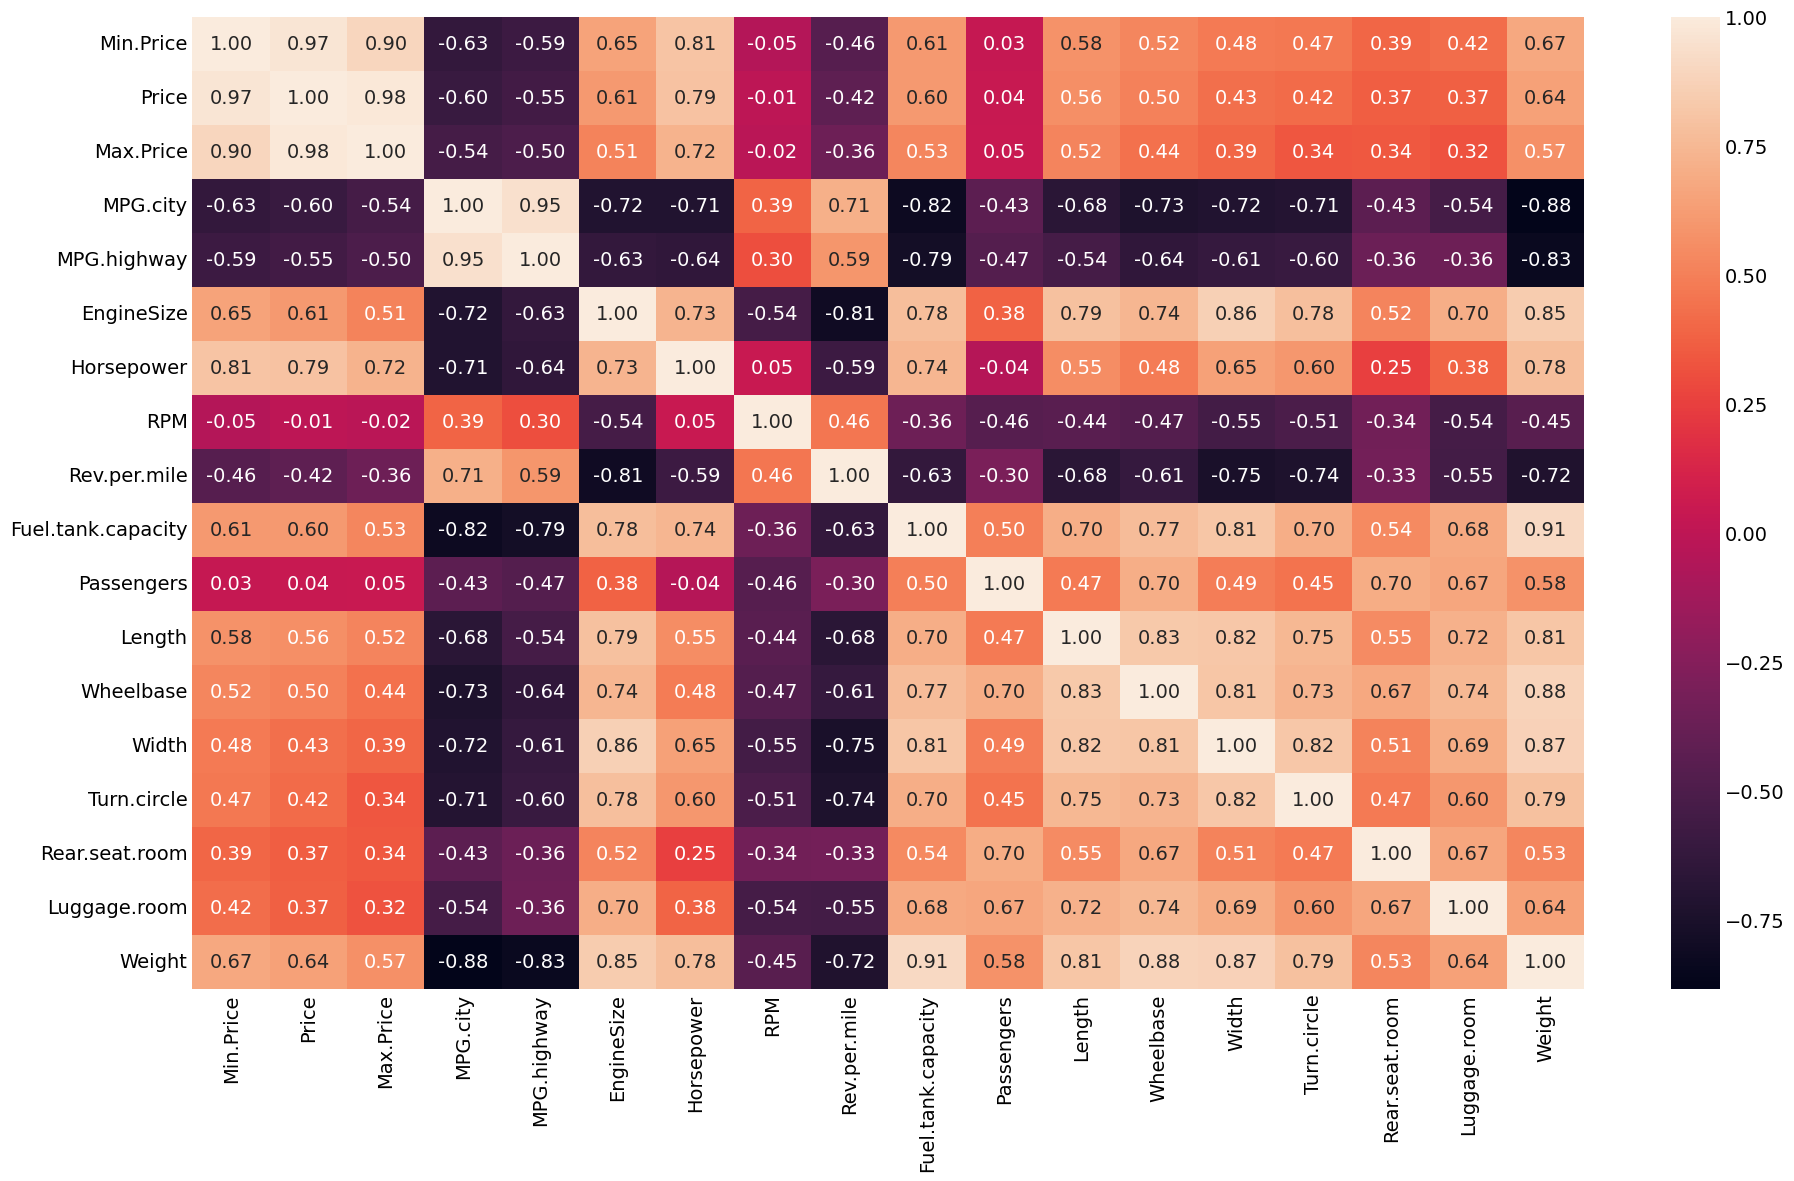

In [7]:
sns.heatmap(df_cars.corr(numeric_only=True), annot=True, fmt=".2f")

There are many more plots that the Seaborn API offers, and it would be impossible to cover all of them. For more details on the possibilities, please refer to the [Seaborn API Documentation](http://seaborn.pydata.org/api.html) and [Seaborn Gallery](http://seaborn.pydata.org/examples/index.html)

#### Exercise 3.1
Using the Seaborn visualization tools explore the wine dataset. Try to understand how the variables are distributed, and what are the variables that are more related to the wine quality.


In [ ]:
df_wine = pd.read_csv("../assets/winequality-white.csv", sep=';')
sns.set_theme()
df_wine.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


<Axes: xlabel='pH', ylabel='Count'>

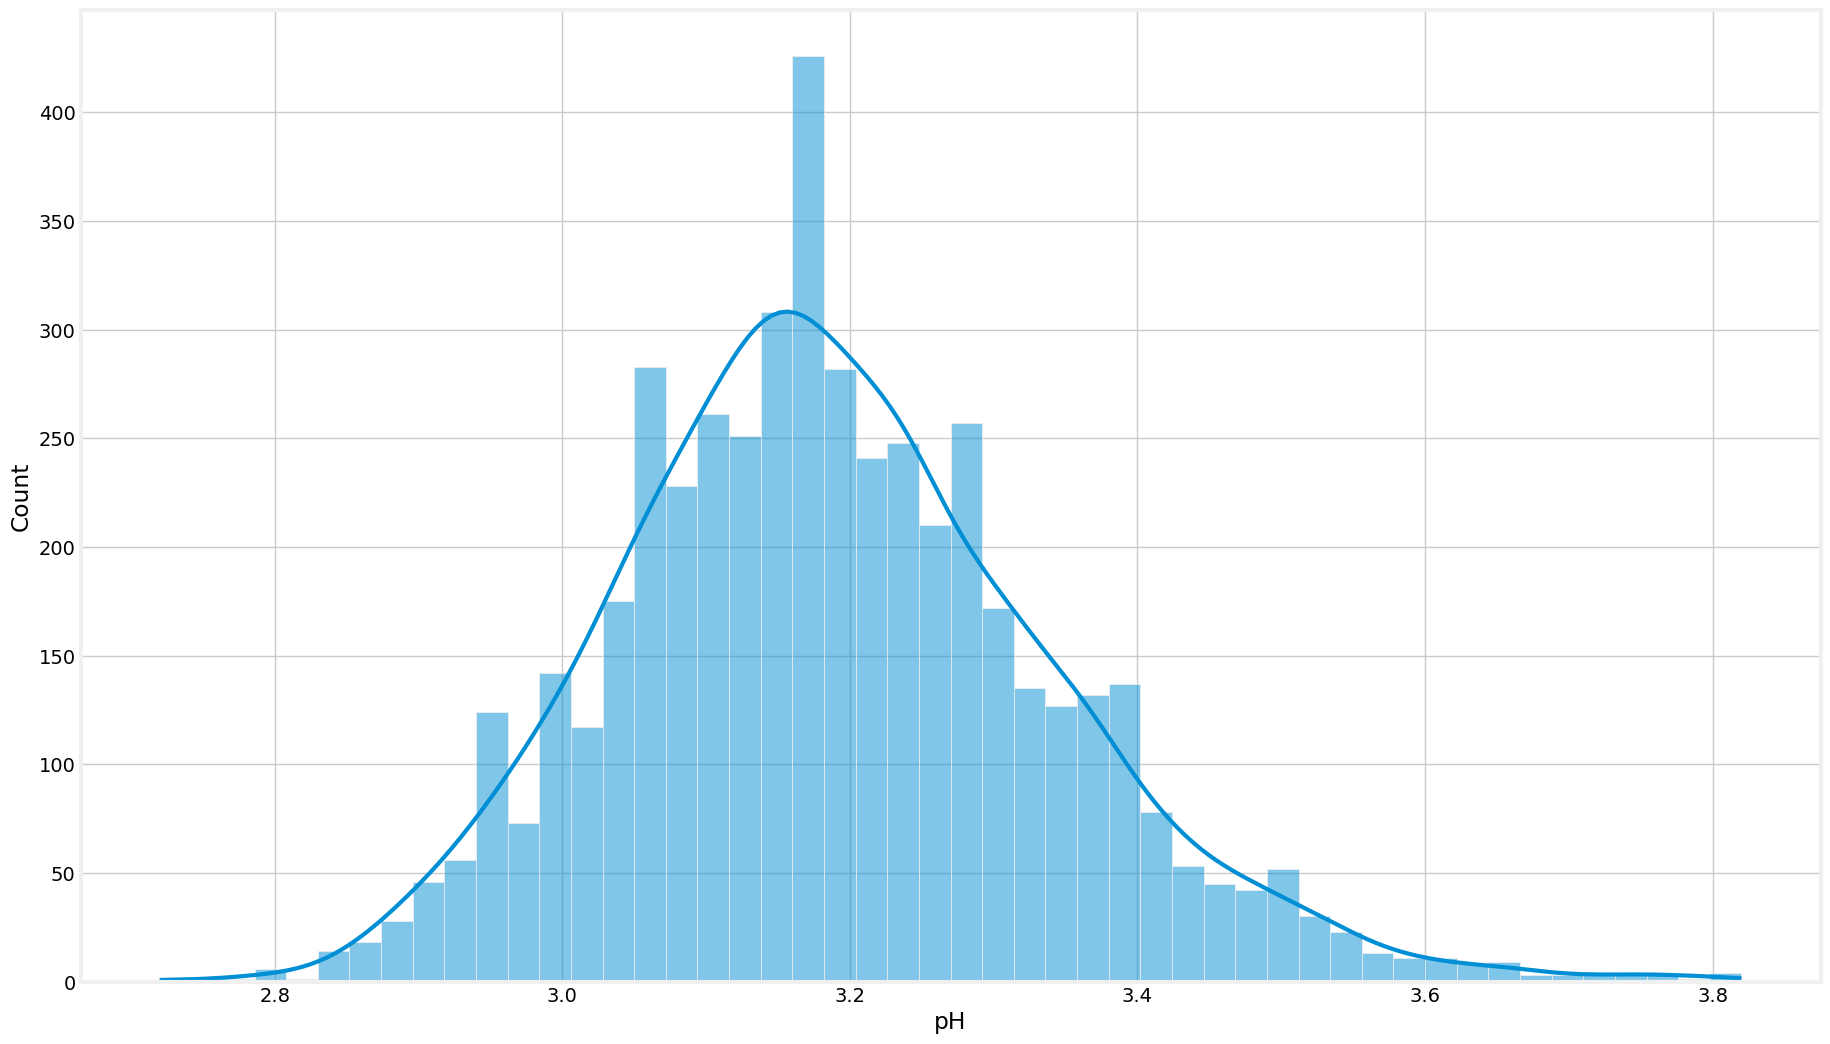

In [16]:
sns.histplot(df_wine['pH'], kde=True)

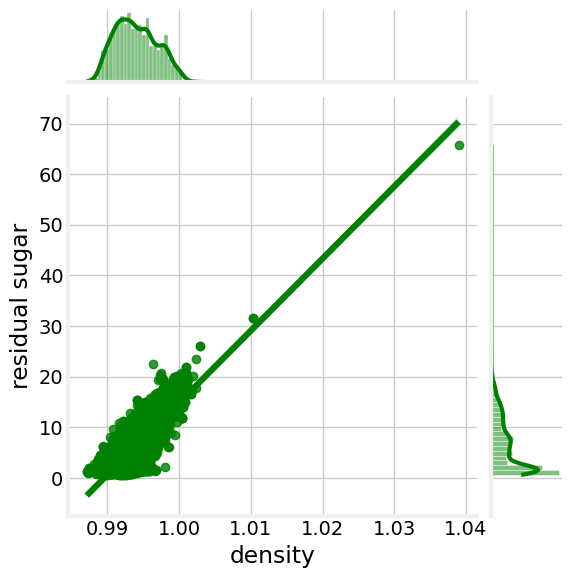

In [17]:
sns.jointplot(data=df_wine, x='density', y='residual sugar', color='g', kind='reg')


<Axes: >

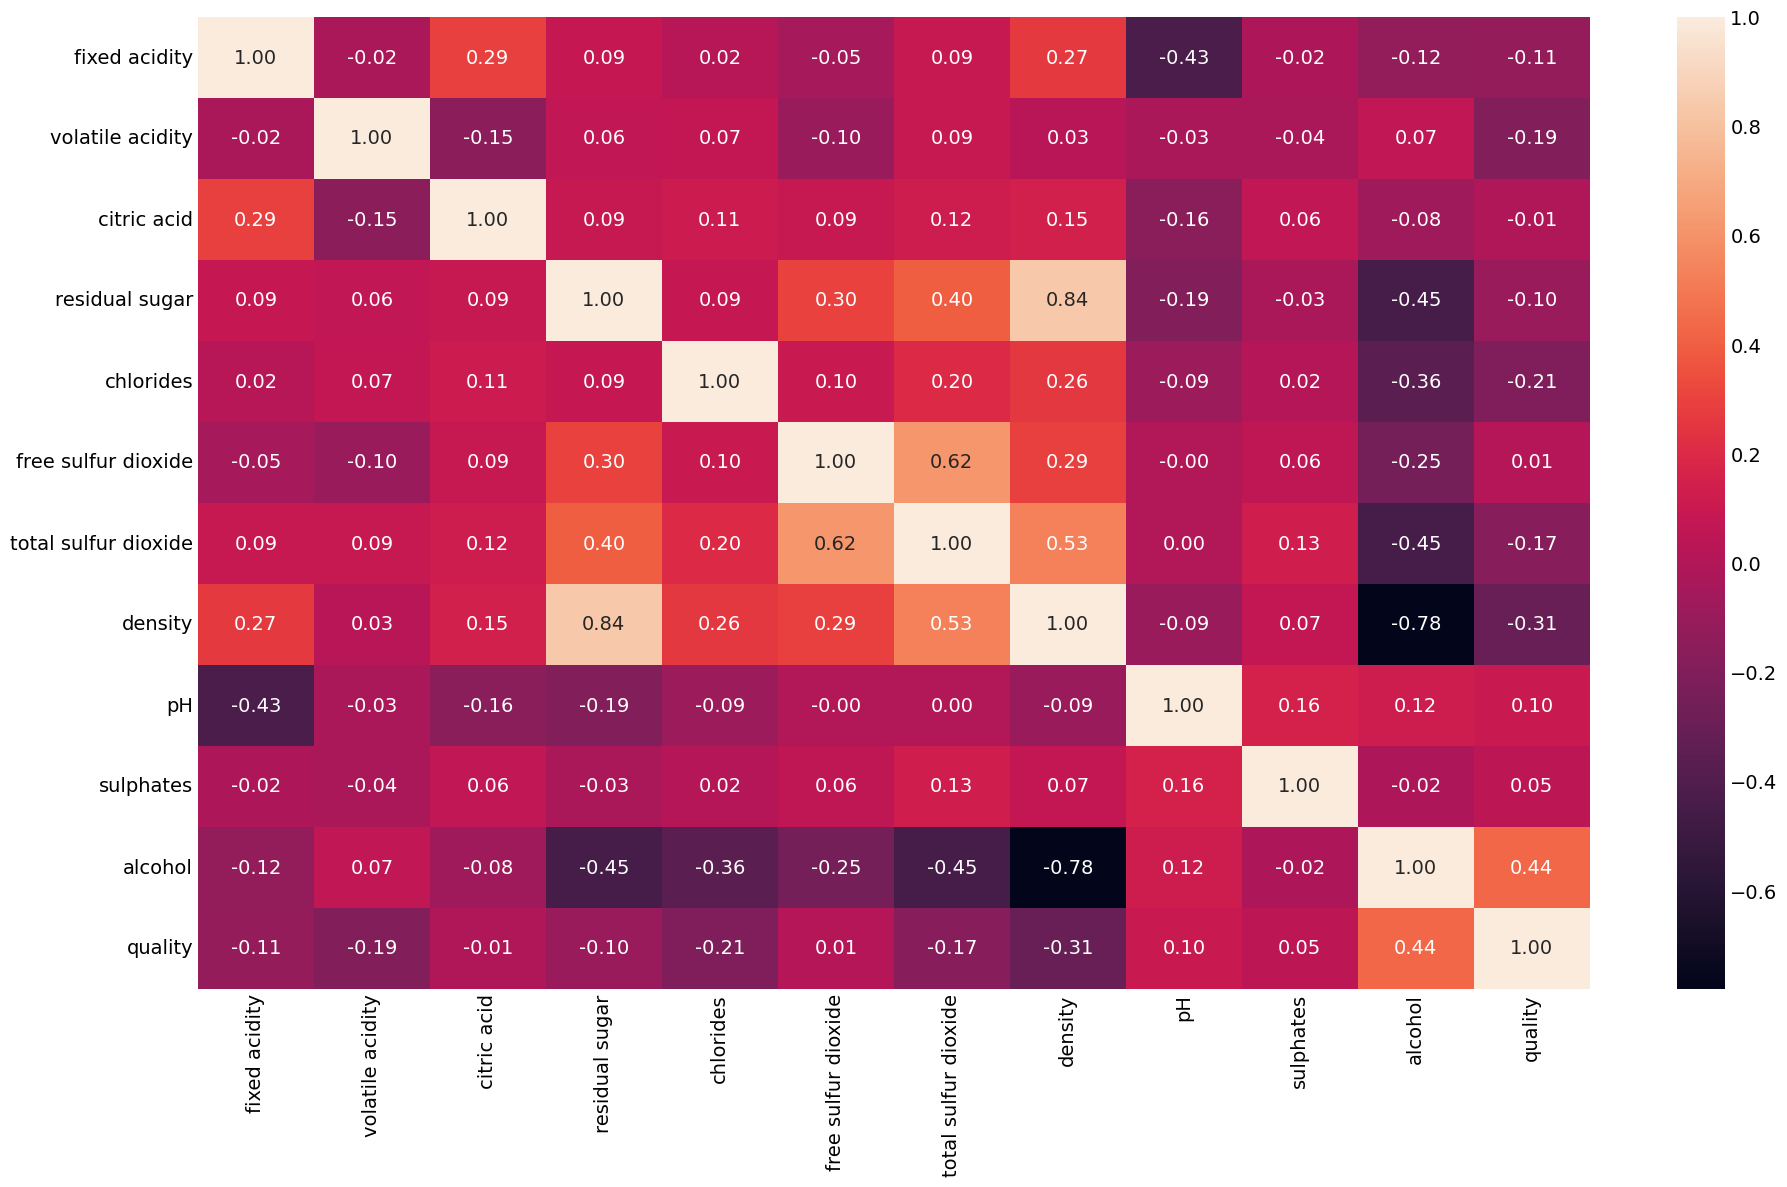

In [18]:
sns.heatmap(df_wine.corr(numeric_only=True), annot=True, fmt=".2f")


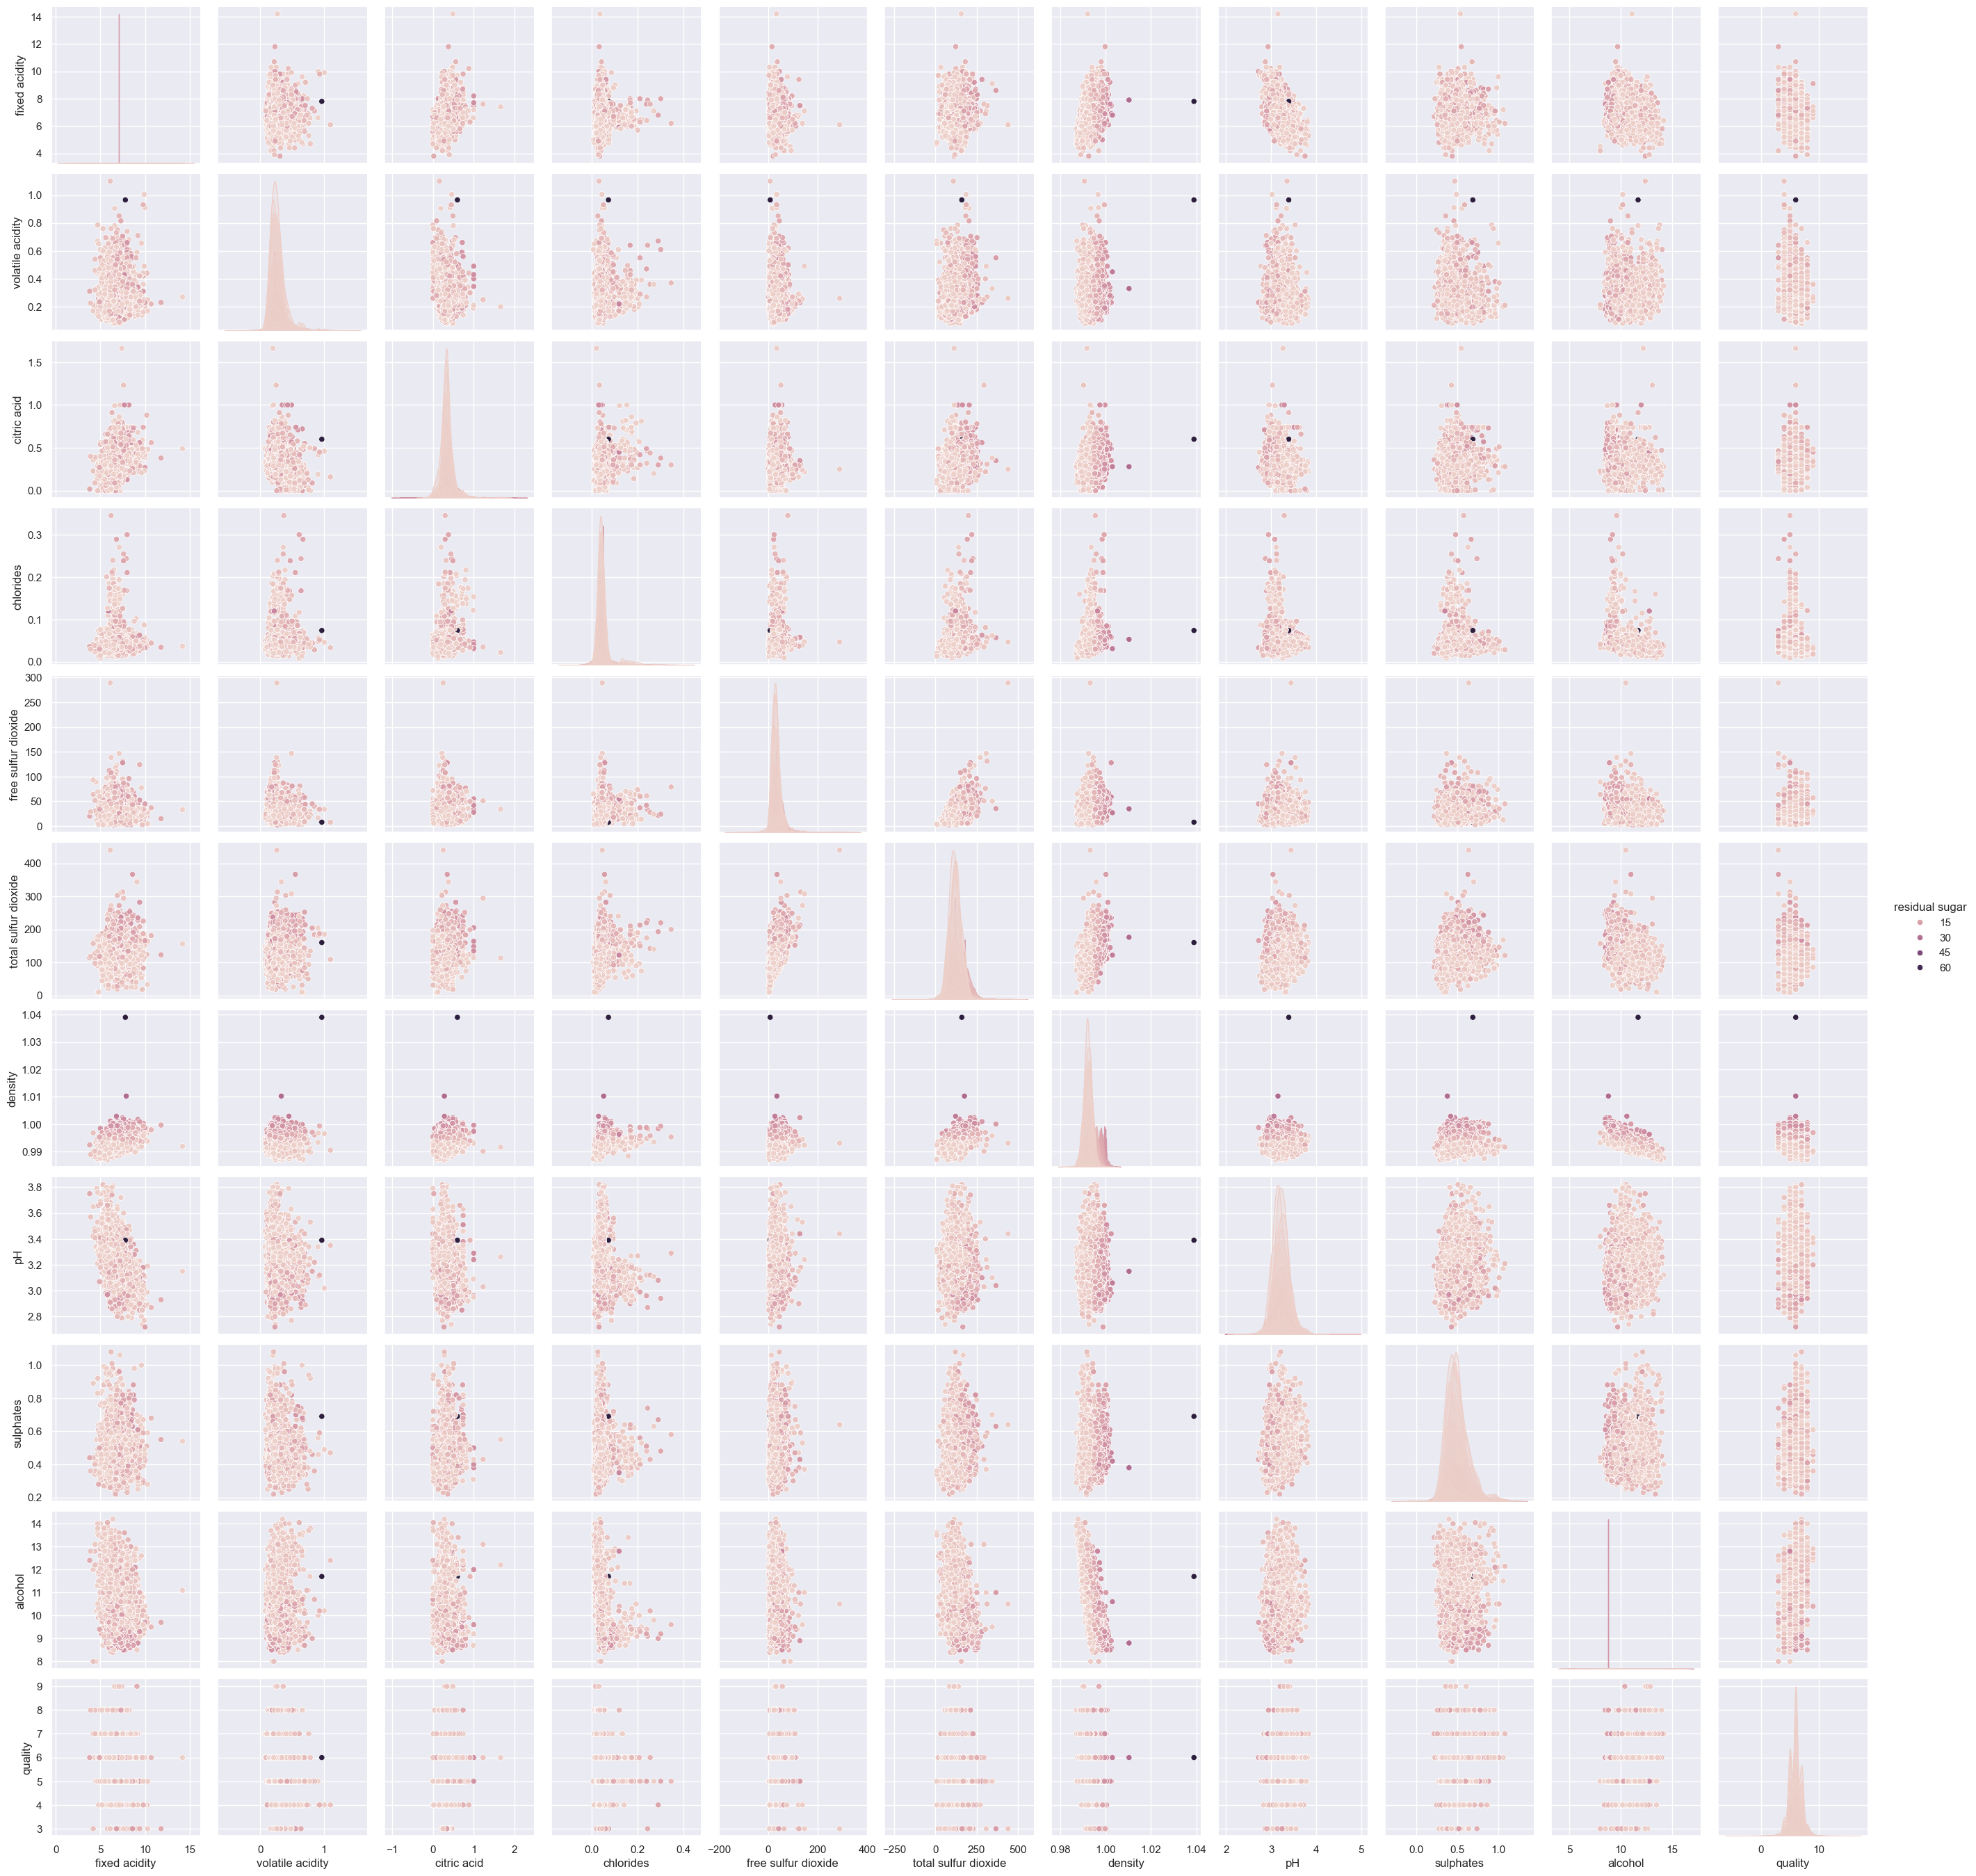

In [33]:
sns.pairplot(data=df_wine, hue='residual sugar')